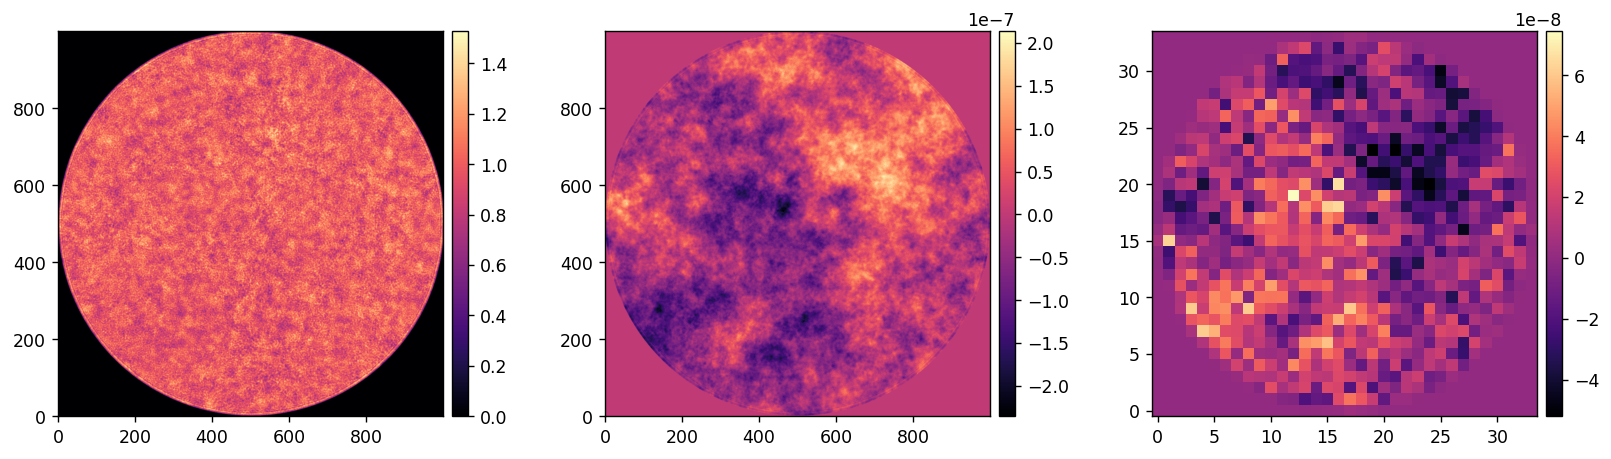

In [31]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import copy
from importlib import reload

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, CenteredNorm
from matplotlib.patches import Circle, Rectangle

from scipy.optimize import minimize

from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel import utils, aefc, props
import esc_fresnel.esc_control_model as esc_cm

wavelength_c = 650e-9

prefpm_amp = utils.load_fits('/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/prefpm_amp.fits')
prefpm_opd = utils.load_fits('/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/prefpm_opd.fits')
dm_flat = xp.rot90(xp.rot90(utils.load_fits('/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_flat.fits')))

utils.imshow([prefpm_amp, prefpm_opd, dm_flat])


Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.


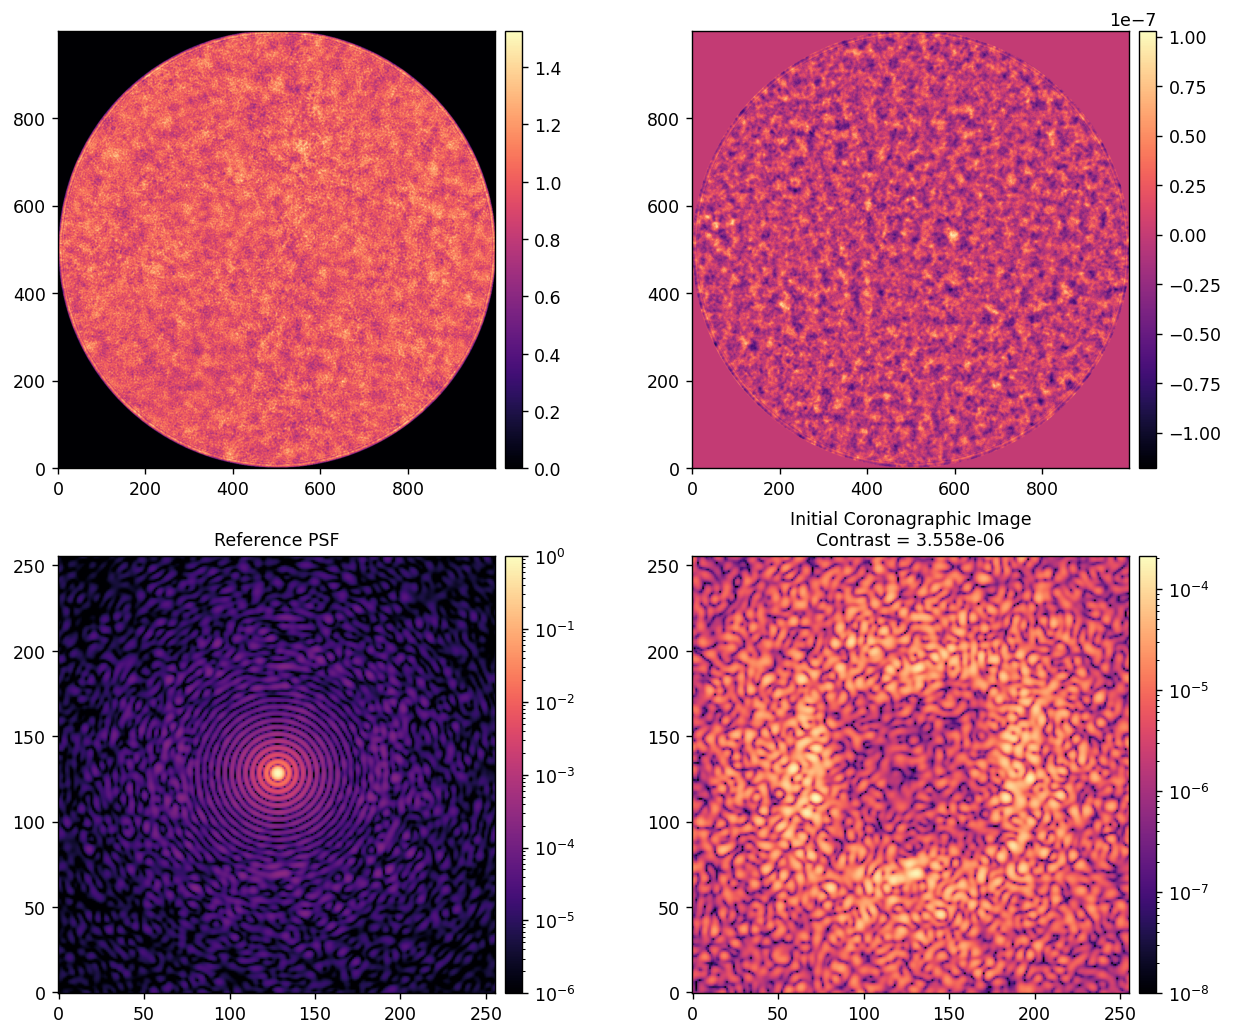

In [55]:
reload(esc_cm)

I = esc_cm.MODEL(
    dm_ref=dm_flat,
)
I.AMP = copy.copy(prefpm_amp)
I.OPD = copy.copy(prefpm_opd)
I.exit_pupil_prop_distance = 200e-3

prefpm_amp_flat, prefpm_opd_flat = I.calc_pupil()

I.use_vortex = 0
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref

I.use_vortex = 1
ref_coro_im = I.snap()

iwa = 3
owa = 10
rot = 90
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
ref_contrast = xp.mean(ref_coro_im[control_mask])

utils.imshow(
    [prefpm_amp_flat, prefpm_opd_flat,
     ref_psf, ref_coro_im],
    titles=[None, None, 'Reference PSF', f'Initial Coronagraphic Image\nContrast = {ref_contrast:.3e}'],
    norms=[Normalize(), Normalize(), LogNorm(1e-6), LogNorm(1e-8)],
    Nrows=2, Ncols=2,
    figsize=(12,10),
    dpi=125,
)

Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.


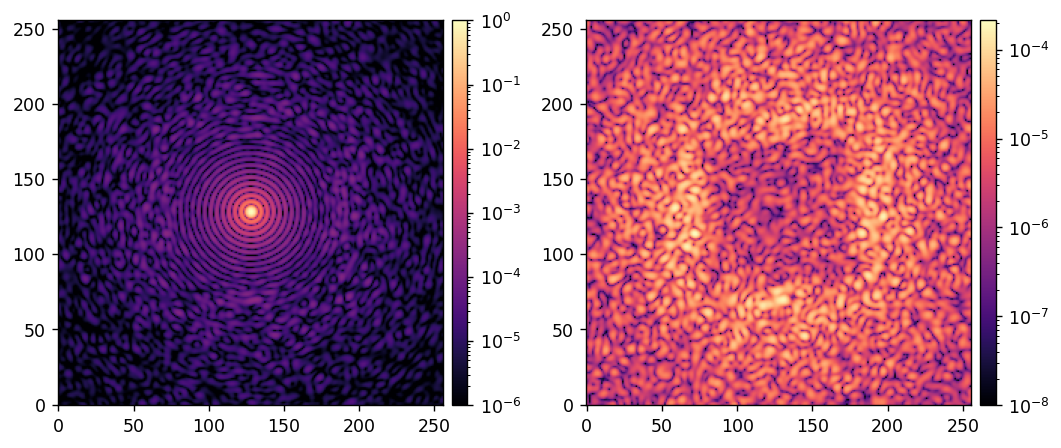

In [56]:
reload(esc_cm)

M = esc_cm.MODEL()
M.AMP = copy.copy(prefpm_amp_flat)
M.OPD = copy.copy(prefpm_opd_flat)

model_psf = xp.abs(M.forward(xp.zeros(M.Nacts), use_vortex=0))**2
M.Imax_ref = xp.max(model_psf)
model_psf /= M.Imax_ref

model_coro_im = xp.abs(M.forward(xp.zeros(M.Nacts)))**2

utils.imshow(
    [model_psf, model_coro_im],
    norms=[LogNorm(1e-6), LogNorm(1e-8)],
)

In [57]:
reload(aefc)
I.reset_dm()
data = {
    'images':[ref_coro_im],
    'contrasts':[ref_contrast],
    'efields':[],
    'commands':[],
    'del_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

Running iteration 7


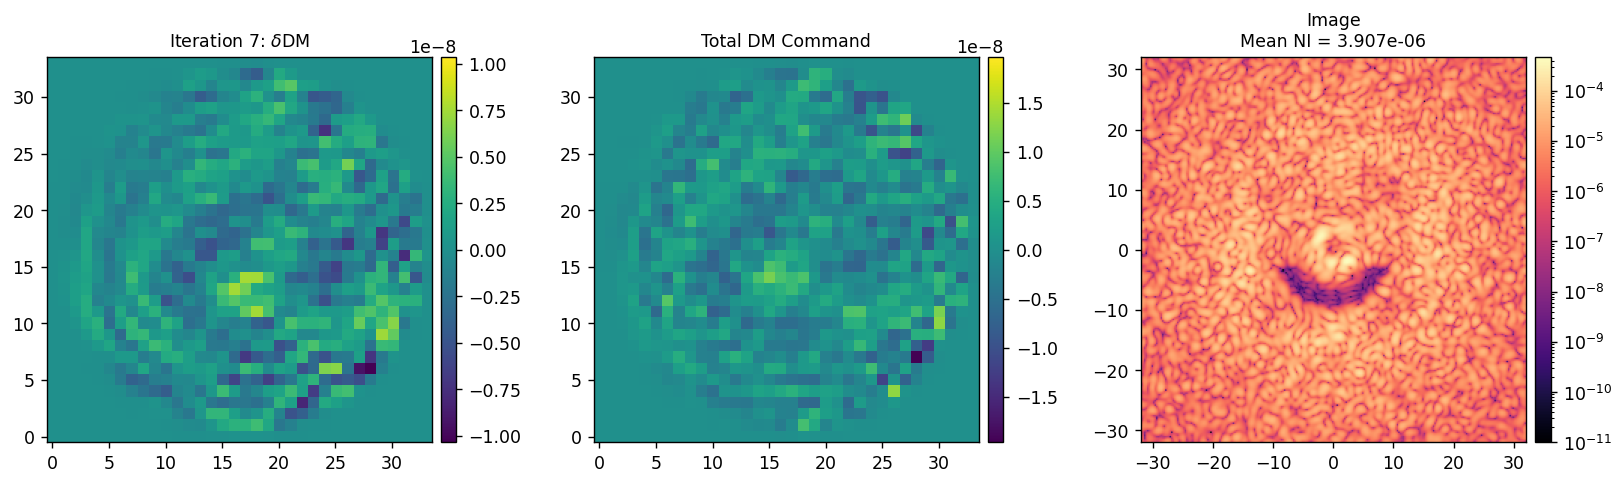

Running iteration 8


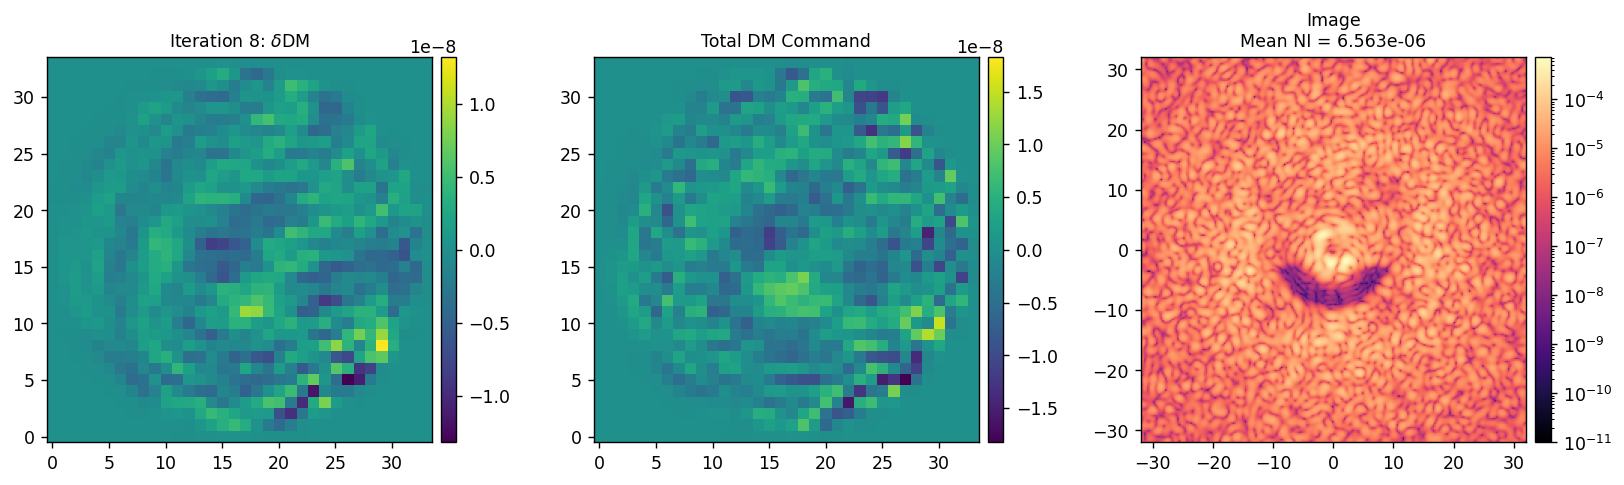

Running iteration 9


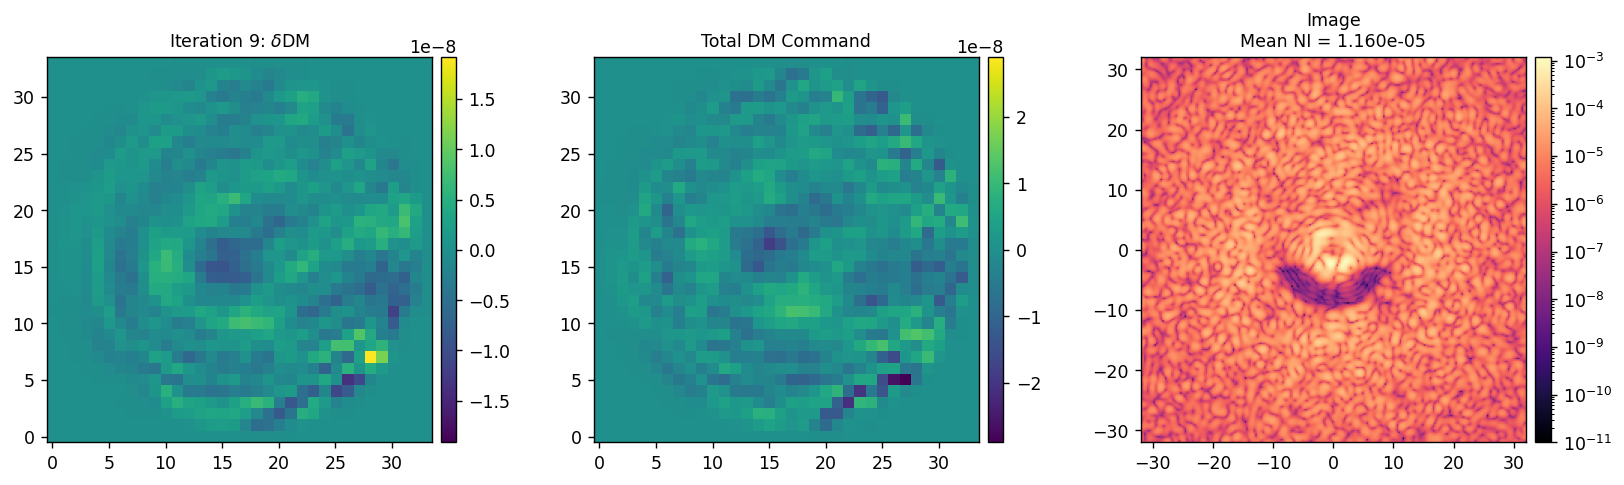

In [60]:
reload(esc_cm)
reload(aefc)
reload(utils)

r_cond = 1e-1
r_cond = 1e-2
r_cond = 1e-3
# r_cond = 1e-4
# r_cond = 1e-5
# r_cond = 1e-6
# r_cond = 1e-7
# r_cond = 1e-8
# r_cond = 1e-10

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5

bfgs_opts = {
    'disp':1,
    'maxiter':50,
    'maxls':10,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run(
    I, 
    M, 
    esc_cm.val_and_grad, 
    control_mask, 
    data,
    Nitr=3, 
    reg_cond=r_cond,
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
    vmin=1e-11,
)